<a href="https://colab.research.google.com/github/Clover130/Seismic-Babes-Group-Project-1/blob/main/EMSC2010_Group_Project_1_Seismic_Babes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Seismic Babes Group Project 1

## 1. Project Overview
Group name: Seismic Babes

Project week: Week 5

Project title: Investigating the Crustal Thickness of Australia and South America using Bootstrapping Techniques

Datasets used (name and source): GPlatesPortal, Crustal and Lithospheric Thickness { https://portal.gplates.org/cesium/?view=crustal_litho_thickness }

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Clover | Owen | YES| Add note|
| Data steward | Freddie | Clover | YES| Add note|
| Analysis / modelling | Ed | Freddie | YES| Add note|
| Visualisation / interpretation | Ellie | Justin | YES| Add note|
| Narrative | Justin | Ellie | YES| Add note|
| Quality Control / Reproducibility  | Owen | Ed | YES| Add note|


#Question
How does the average crustal thickness of the Australian continent compare to that of the South American continent?

Can we reliably estimate this difference using random spatial sampling and bootstrapping?

#Motivation and Justification

Understanding crustal thickness is a basic but important step in interpreting the tectonic and geological history and stability across the different continents.

Two separate locations, South America and Australia, we hypothesise, are largely different. South America features active tectonic margins alongside ancient cratons, whereas Australia is largely intraplate, ancient, and stable.

By comparing these two continents, we aim to investigate how different tectonic settings influence average crustal thickness.

The team set the scope to focus on 40 randomly generated spatial points per continent. This sample size keeps data collection manageable while allowing us to use the bootstrap method to estimate the true mean with confidence.


## Statistical Methodology

To ensure an unbiased comparison between the two continents, we avoided cherry-picking data by generating pseudo-random coordinates. Due to the relatively small sampling size (n=40), we must avoid the assumption that this dataset is a true representation of the entire continent.

To account for this issue, the team applied bootstrapping techniques. By resampling our 40 data points (with replacement) 1,000 times, we hope to effectively simulate the broader population of thicknesses across each continent.

This statistical technique allows us to estimate the sampling distribution of the mean and calculate 95% confidence intervals for both continents.

By comparing both distributions, we are able to directly answer our research question by giving us a statistically sound way to see if the average crustal thicknesses significantly differ.

## STEP 1: Random point generation

The first step in acquiring data was to establish a repeatable methodology to create random data points for the two areas of interest. For this example, the team decided to use Australia and South America.

To achieve random or pseudo-random points (since it is still computer-generated) a few requirements are applied. The team decided to utilise the Python fucntion 'Random' to actively select points based on the two contents.

Thus, we needed to create a shp file with the bounds, i.e., latitude and longitude. To produce a .shp file that could be imported into Python, we downloaded a global coastline geopackage from the open-source website Natural Earth (https://www.naturalearthdata.com/downloads/). A 110-meter-resolution geopackage was acquired and processed in QGIS 3.40.

From here, the continent of interest was isolated and exported as a shapefile for import into Python. Using this newly created shapefile of Australia and South America, we adapted pre-existing code sourced from stackoverflow.com (https://stackoverflow.com/questions/60534219/pyshp-generate-random-points-in-shapefile).

By adapting this code, we successfully generated random points within the area of interest and saved them, along with their respective latitudes and longitudes, to a CSV file for further processing. This process was completed for both the Australian and the South American shapefiles. More instructions on the individual purpose and process of the code are explained within the cell.

Imported files are:
- Final_aus_bound.shp
- Final_aus-bound.shx
- south_amerrica.shp
- south_amerrica.shx

Note: in this case we have disregarded Earth as a sphere in our generation of random points. Hence a more reliable method would involve generating random points on a sphere and selecting those that fit within the defined continental boundary

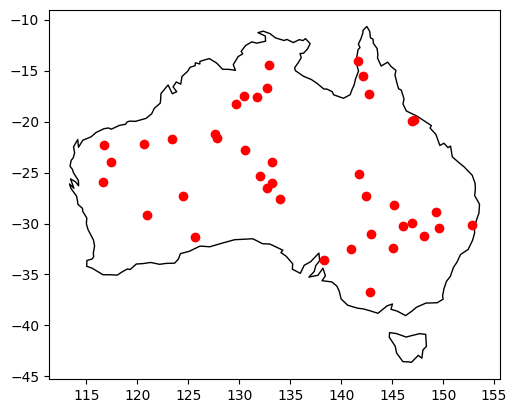

In [2]:
## Code sourced and adpated from (https://stackoverflow.com/questions/60534219/pyshp-generate-random-points-in-shapefile) commentor "dzang"
import random
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

# Initial shapefile created in QGIS is to be loaded and assigned
AUS_shapfile = "Final_aus_bound.shp"
gdf = gpd.read_file(AUS_shapfile)

### altered original code-
# e.g (aoi = gdf[gdf['ZCTA5CE10'] == zcta_to_use]) was not used as this was
# specific to find a specific zipcode
# within the shapfile in America; therefore, it was not needed for this
# Australian shapefile. (AI helped me identify this as an error.

# combine all polygons into one, this is grabbing all the individual shapefiles
# and collating them into one big shapefile or polygon.

aoi_geom = gdf.union_all()

# This assigns how many random points are to be generated within the shapefile bounds.

pointcount = 40

# The purpose of this code is to assign a min and max for both the x and y
# coordinates. What are the furthest northern and southern longitudes, and what
# are the furthest eastern and western latitudes?Thus, we end up with a
# rectangle around an Australian ready for the next step.

xmin, ymin, xmax, ymax = aoi_geom.bounds

# Now, with the newly created rectangle/bounding box around Australia, we
# started assigning pseudo-random points!using the analogy of throwing darts,
# the computer will continue to throw darts within the bounding box until 40 darts
#land within the shapfile ie Australia

points = []
while len(points) < pointcount:
    x = random.uniform(xmin, xmax)
    y = random.uniform(ymin, ymax)
    p = Point(x, y)

    if p.within(aoi_geom):
        points.append(p)

## this just gets all the random points we just generated and puts them into a
# series to allow for easier handling

gs = gpd.GeoSeries(points)

# to validate the random points, we can just plot to ensure all points are
# actually within the defined shapefile, and the latitude and longitude correctly
# match what we expect for Australia.

fig, ax = plt.subplots()
gdf.plot(ax=ax, facecolor='none', edgecolor='black')
gs.plot(ax=ax, color='red')

plt.show()


# finally, to hand over to the data import team member the newly generated
# points and the corresponding latitude and longitude needs to be a CSV file.


gs.to_csv("/content/AUS_random_points.csv", index=False)


## rinse and repeat for the South America shapefile, and we have our two datasets!!!
##-JUSTIN'S code


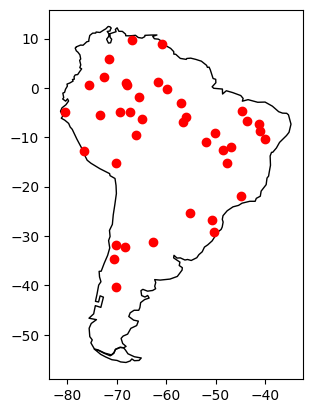

In [3]:
## Code sourced and adpated from (https://stackoverflow.com/questions/60534219/pyshp-generate-random-points-in-shapefile) commentor "dzang"
import random
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

# Initial shapefile created in QGIS is to be loaded and assigned
SA_shapfile = "south_amerrica.shp"
gdf_SA = gpd.read_file(SA_shapfile)

### altered original code-
# e.g (aoi = gdf[gdf['ZCTA5CE10'] == zcta_to_use]) was not used as this was
# specific to find a specific zipcode within the shapfile in America; therefore,
# it was not needed for this South American shapefile. (AI helped me identify this
# as an error.

# combine all polygons into one, this is grabbing all the individual shapefiles
# and collating them into one big polygon.

aoi_geom_SA = gdf_SA.union_all()

# This assigns how many random points are to be generated within the shapefile bounds.

SA_pointcount = 40

# The purpose of this code is to assign a min and max for both the x and y
# coordinates. What are the furthest northern and southern longitudes, and what
# are the furthest eastern and western latitudes?
#Thus, we end up with a rectangle around an South America ready for the next step.

xmin_SA, ymin_SA, xmax_SA, ymax_SA = aoi_geom_SA.bounds

# Now, with the newly created rectangle/bounding box around South America, we
# started assigning pseudo-random points! using the analogy of throwing darts,
# the computer will continue to throw darts within the bounding box until 40 darts
#land within the shapfile ie South America

SA_points = []
while len(SA_points) < SA_pointcount:
    x_SA = random.uniform(xmin_SA, xmax_SA)
    y_SA = random.uniform(ymin_SA, ymax_SA)
    p_SA = Point(x_SA, y_SA)

    if p_SA.within(aoi_geom_SA):
        SA_points.append(p_SA)

# this just gets all the random points we just generated and puts them into a
# series to allow for easier handling

gs_SA = gpd.GeoSeries(SA_points)

# to validate the random points, we can just plot to ensure all points are
# actually within the defined shapefile, and the latitude and longitude
# correctly match what we expect for South America.

fig_SA, ax_SA = plt.subplots()
gdf_SA.plot(ax=ax_SA, facecolor='none', edgecolor='black')
gs_SA.plot(ax=ax_SA, color='red')

plt.show()


# finally, to hand over to the data import team member the newly generated
# points and the corresponding latitude and longitude needs to be a CSV file
# needs to be

gs_SA.to_csv("/content/SA_random_points.csv", index=False)

##-JUSTIN'S code




## STEP 2: Data Import


With the newly created .csv files, containing the randomly generated coordinates located on the South American Continent and the other containing the Australian points, we proceeded to take each coordinate and used the program Gplates bu Cesium (https://portal.gplates.org/cesium/?view=crustal_litho_thickness), to find the continental crust thickness at these specific coordinates. We used 40 points for each continent.


**Uncertainty & Limitation**

The Crustal And Lithospheric Thickness data mapped on the GPlates Portal 'virtual globe' was developed using data from the paper *'A global reference model of the lithosphere and upper mantle from joint inversion and analysis of multiple data sets'* (Afonso et al. 2019).  While no specific uncertainty was listed for the global interpolation, by either Afonso and colleagues or listed in available metadata on the GPlates Portal. However, it is suggested by Afonso and colleagues (2016, p. 25) that 'the predicted crustal thickness in LithoRef18 has changed by ±5 km from the initial values in a significant part of the globe'.


Note: as this data set is an interpolated grid, original observations would be better suited to bootstrapping in an ideal analysis

**Reference**: Afonso, J.C., Salajegheh, F., Szwillus, W., Ebbing, J., and Gaina, C., 2019. A global reference model of the lithosphere and upper mantle from joint inversion and analysis of multiple data sets. Geophysical Journal International, 217 (3), 1602–1628.https://doi.org/10.1093/gji/ggz094


**FAIR Data Principles:**

Findability: GPlates Web Portal is a publicly accessible crustal thickness dataset, the specific random points used for this analysis is stored in the 'Seismic Babes Group Project 1 Datasest' file.  

Accessibility: The portal is freely accessible for the data collection to be repeated and dataset used for this analysis is stored in the repository.

Interoperability: Data is stored in an Excel file which can be processed by standard analysis tools such as pandas. Colum names are standard and the coordinate data uses standard convention.

Reusability: Metadata is included for each part of data allowing for reproduction of the dataset. Additionally the method of collection is well documented in this notebook.

In [2]:
import pandas as pd

file_name = "Seismic Babes_Group Project 1_DataSet.xlsx"

df = pd.read_excel(file_name, header=None)

df_AU = pd.read_excel(file_name, sheet_name='AU')
df_SA = pd.read_excel(file_name, sheet_name='SA')

# Extract crustal thickness data for South America and Australia
X = df_AU['Crustal Thickness (m)']
Y = df_SA['Crustal Thickness (m)']

# Find completely blank rows
blank_rows = df[df.isnull().all(axis=1)].index

if len(blank_rows) == 0:
    raise ValueError("No blank rows found — cannot split tables")

# Split tables safely
table1 = df.iloc[:blank_rows[0]].reset_index(drop=True)
table2 = df.iloc[blank_rows[0] + 1:].reset_index(drop=True)

# Only set headers if tables are not empty
if not table1.empty:
    table1.columns = table1.iloc[0]
    table1 = table1[1:].reset_index(drop=True)
else:
    print("Warning: Table 1 is empty")

if not table2.empty:
    table2.columns = table2.iloc[0]
    table2 = table2[1:].reset_index(drop=True)
else:
    print("Warning: Table 2 is empty")

print("Table 1:")
print(table1)

print("\nTable 2:")
print(table2)

Table 1:
Empty DataFrame
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Index: []

Table 2:
0   NaN Point #    Longitude      Latitude   \
0   NaN       1    -74.496015     -49.55041   
1   NaN       2    -55.125278     -27.82794   
2   NaN       3    -57.220806     -4.890713   
3   NaN       4    -46.871095    -13.320275   
4   NaN       5    -51.014127     -3.364726   
5   NaN       6    -66.392963      -3.72581   
6   NaN       7     -66.43568      8.502381   
7   NaN       8    -67.152112    -26.383269   
8   NaN       9     -71.19033    -10.417772   
9   NaN      10    -61.179751     -7.622409   
10  NaN      11    -64.991079    -35.405326   
11  NaN      12    -56.734374    -30.078724   
12  NaN      13    -36.956091     -6.621703   
13  NaN      14    -77.481836      0.016169   
14  NaN      15    -52.853689    -29.597547   
15  NaN      16    -35.551225     -5.522559   
16  NaN      17    -38.340573     -7.149303   
17  NaN      18    -67.803363    -16.009012   
18  NaN      19    -61

## STEP 3: Data Analysis

**Preliminary Data Analysis:**
1. The extracted array of crustal thickness for each continent (X and Y) is used for analysis

2. Prior to any statistical methods were performed, Basic Summary statistic were preformed.

3. The mean, inter-quartile range and standard deviation were identified while a box and whisker plot and histogram  were formed

**Bootstrap Methods:**

Completed for each continent (Australia and South America)

1. Original Samples = 40 crustal thickness measurements (in meters)

2. Resampling
- Randomly sample 40 values FROM the original 40 (with replacement)
- This creates one "bootstrap sample"

3. Calculate Statistic
- identify the mean crust thickness for this sample ^
  
4. Repeat
- repeat steps 2-3 a total of 10,000 times
- This gives us 10,000 bootstrap means

5. Estimate Confidence Interval
- 10,000 bootstrap means find
- 95% CI = [2.5th percentile, 97.5th percentile]
- This represents our uncertainty in the true mean

### Australia Crustal Thickness Bootstrapping

Mean 36178.7
IQR 5608.5
Standard Deviation 3574.0752384358116


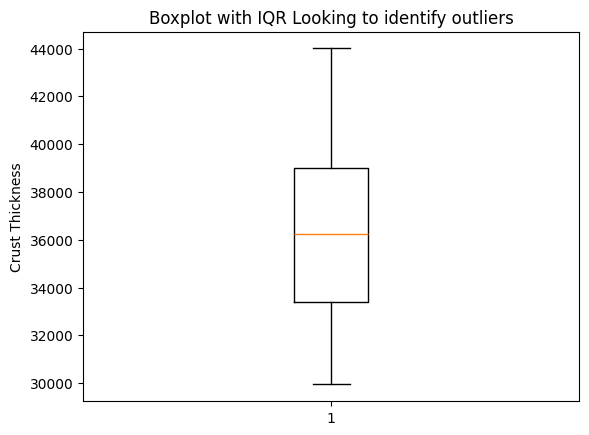

6.324555320336759


<function matplotlib.pyplot.show(close=None, block=None)>

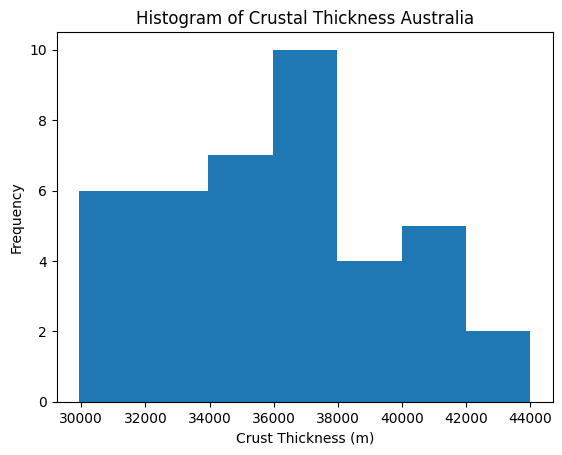

In [12]:
import numpy as np
import matplotlib.pyplot as plt

#basic summary stats of raw data, ensuring no extreme outliers that could
#extreme skew of the random data could be unrepresenative of bootstrapped data causing an artifact.
## need mean, Inter quartile range-and plot for outliers , and standard diviation of the raw data

##summary stats
Mean_X = np.mean(X)
print('Mean', Mean_X)

## finding IQR to look for outliers
Q1_X = np.percentile(X,25)
Q3_X = np.percentile(X,75)
IQR_X = Q3_X -Q1_X
print('IQR', IQR_X)

## STD OF RAW DATA
std_X = np.std(X)
print('Standard Deviation', std_X)

#simple Boxplot to identify possible outliers

plt.boxplot(X)
plt.title('Boxplot with IQR Looking to identify outliers')
plt.ylabel('Crust Thickness')
plt.show()

### taking SQRT to find bin numbers
# math.sqrt(len(X))
print(np.sqrt(len(X)))
## sqrt of 40 to give approiate amount of bins

# Plotting dist to see if there is any skew in the raw data.

plt.hist(X, bins=7)
plt.title('Histogram of Crustal Thickness Australia')
plt.xlabel('Crust Thickness (m)')
plt.ylabel('Frequency')
plt.show

In [5]:
A = np.random.choice(X, size=(len(X),100000), replace=True)
print(np.shape(A))

## A represents a random selection from the data (with replacement)

(40, 100000)


In [6]:
barA = np.mean(A, axis=0)
print(np.shape(barA))

## barA represents the mean of columns of the bootstrapped crustal thicknesses data

(100000,)


In [7]:
CI_A = np.percentile(barA,[2.5,97.5])
Mean_A = np.mean(barA)
print(CI_A)
print(Mean_A)

## Computing confidence interval for Australia crustal thickness

[35072.918125 37294.93    ]
36180.356348


### South American Crustal Thickness Bootstrapping

Mean: 37793.525
IQR: 4349.25
Standard Deviation: 7198.035909147369


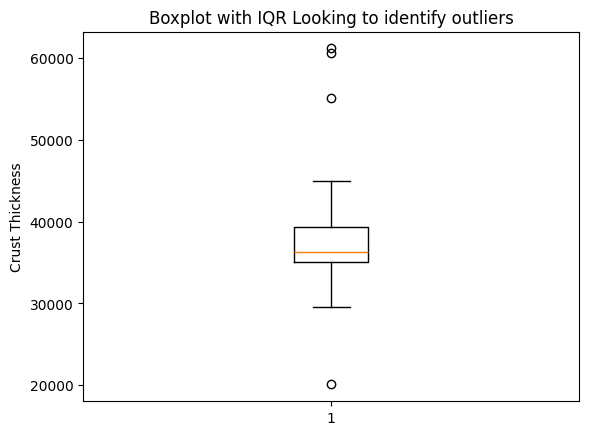

6.324555320336759


<function matplotlib.pyplot.show(close=None, block=None)>

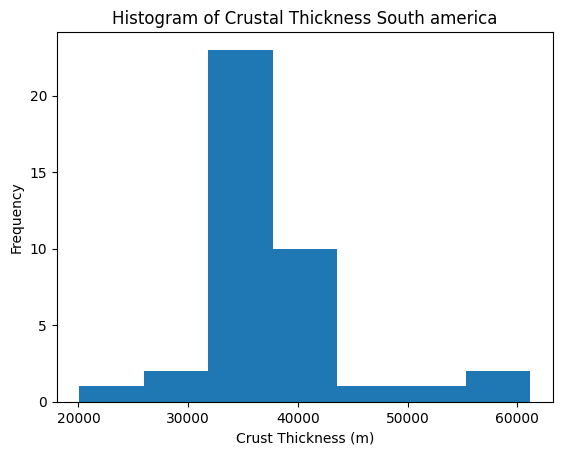

In [16]:
#basic summary stats of raw data, ensuring no extreme outliers that could
#extreme skew of the random data could be unrepresenative of bootstrapped data causing an artifact.
## need mean, Inter quartile range-and plot for outliers , and standard diviation of the raw data

##summary stats
Mean_Y = np.mean(Y)
print('Mean:', Mean_Y)
## finding IQR to look for outliers
Q1_Y = np.percentile(Y,25)
Q3_Y = np.percentile(Y,75)
IQR_Y = Q3_Y -Q1_Y
print('IQR:', IQR_Y)

## STD OF RAW DATA
std_Y = np.std(Y)
print('Standard Deviation:', std_Y)

#simple Boxplot to indetify possible outliers

plt.boxplot(Y)
plt.title('Boxplot with IQR Looking to identify outliers')
plt.ylabel('Crust Thickness')
plt.show()

### taking SQRT TO FIND BIN NUM
# math.sqrt(len(X))
print(np.sqrt(len(Y)))
## sqrt of 40 to give approiate amount of bins

# Plotting dist to see if there is any skew in the raw data.

plt.hist(Y, bins=7)
plt.title('Histogram of Crustal Thickness South america')
plt.xlabel('Crust Thickness (m)')
plt.ylabel('Frequency')
plt.show

In [17]:
S = np.random.choice(Y, size=(len(Y),100000), replace=True)
print(np.shape(S))

## S represents a random selection from the data (with replacement)

(40, 100000)


In [18]:
barS = np.mean(S, axis=0)
print(np.shape(barS))

## barS represents the mean of columns of the bootstrapped crustal thicknesses data

(100000,)


In [19]:
CI_S = np.percentile(barS,[2.5,97.5])
Mean_S=np.mean(barS)

print(CI_S)
print(Mean_S)

## Computing confidence interval for South American crustal thickness

[35701.274375 40163.826875]
37791.95159275


#STEP 4: Results and Interpretation
The initial analysis of the raw data reveals that South America has a standard deviation double that of Australia (South America = 7.2km, Australia = 3.6km). Additionally, the data set contains prominent outliers in South America. This indicates that South America has a much greater range of crustal thickness than Australia.

Following the bootstrapping process, the estimated mean crust thickness for Australia is 36km meters, with a 95% confidence interval between 35km and 37km. In comparison, South America's mean crustal thickness is 38km, with 95% confidence intervals of 36km and 40km.

## Data Visualisation

Two data visualisation methods were used to effectively show and communicate the results of the experiment.
Distributions were used to demonstrate the spread of data and mapping of the plots was used to clearly display the distribution relative to position

Histograms

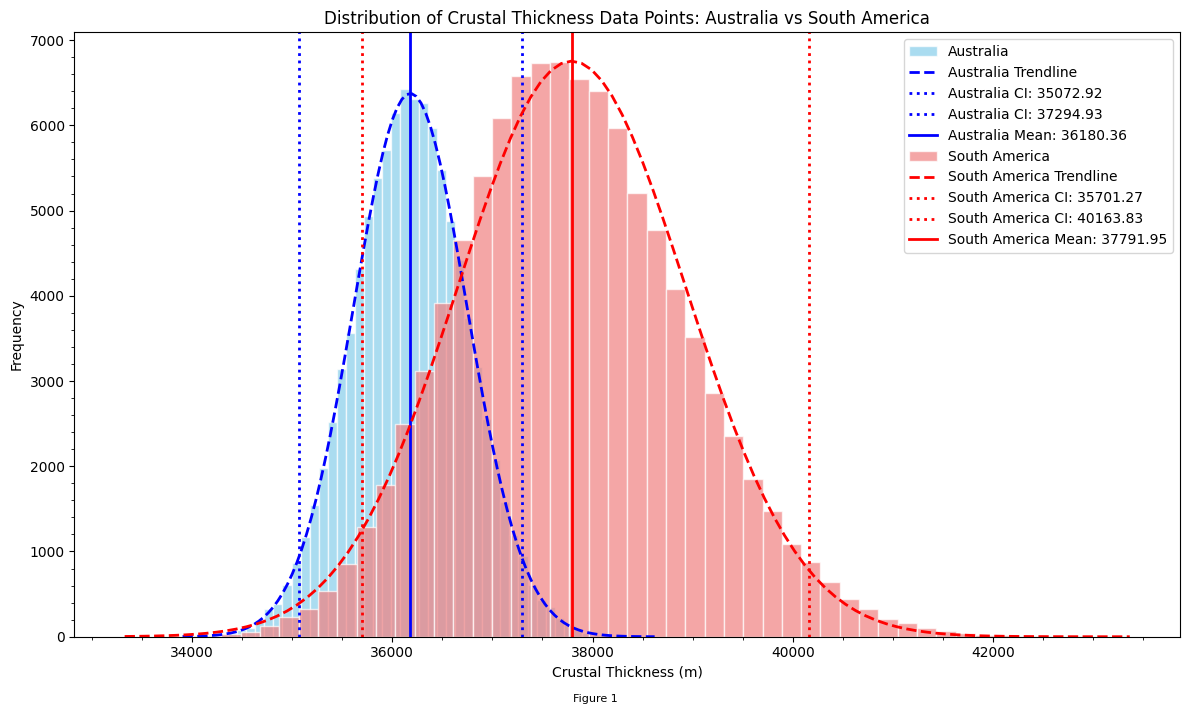

In [31]:
#AI Statment

#We used Gemini in-built assistant to assist in taking the current code and
#effectively plot the two distributions against one another. Additionally, it
#assisted with adding appropriate lines to show mean,CI and the trendline


fig, ax = plt.subplots(figsize=(12, 7))

# Plot histogram for Australia (barA)
n_A, bins_A, patches_A = ax.hist(
    barA,
    bins=52,
    alpha=0.7,
    label='Australia',
    color='skyblue',
    edgecolor='white'
)

# Calculate and plot trendline for Australia
mu_A = np.mean(barA)
std_A = np.std(barA)
x_A = np.linspace(barA.min(), barA.max(), 100)
p_A = np.exp(-0.5 * ((x_A - mu_A) / std_A) ** 2) / (std_A * np.sqrt(2 * np.pi))
p_scaled_A = p_A * len(barA) * (bins_A[1] - bins_A[0])
ax.plot(x_A, p_scaled_A, color='blue', linewidth=2, linestyle='--', label='Australia Trendline')

# Plot confidence interval for Australia
ax.axvline(CI_A[0], color='blue', linestyle=':', linewidth=2, label=f'Australia CI: {CI_A[0]:.2f}')
ax.axvline(CI_A[1], color='blue', linestyle=':', linewidth=2, label=f'Australia CI: {CI_A[1]:.2f}')
# Plot mean for Australia
ax.axvline(Mean_A, color='blue', linestyle='-', linewidth=2, label=f'Australia Mean: {Mean_A:.2f}')

# Plot histogram for South America (barS)
n_S, bins_S, patches_S = ax.hist(
    barS,
    bins=52,
    alpha=0.7,
    label='South America',
    color='lightcoral',
    edgecolor='white'
)

# Calculate and plot trendline for South America
mu_S = np.mean(barS)
std_S = np.std(barS)
x_S = np.linspace(barS.min(), barS.max(), 100)
p_S = np.exp(-0.5 * ((x_S - mu_S) / std_S) ** 2) / (std_S * np.sqrt(2 * np.pi))
p_scaled_S = p_S * len(barS) * (bins_S[1] - bins_S[0])
ax.plot(x_S, p_scaled_S, color='red', linewidth=2, linestyle='--', label='South America Trendline')

# Plot confidence interval for South America
ax.axvline(CI_S[0], color='red', linestyle=':', linewidth=2, label=f'South America CI: {CI_S[0]:.2f}')
ax.axvline(CI_S[1], color='red', linestyle=':', linewidth=2, label=f'South America CI: {CI_S[1]:.2f}')
# Plot mean for South America
ax.axvline(Mean_S, color='red', linestyle='-', linewidth=2, label=f'South America Mean: {Mean_S:.2f}')

# Formating histogram
ax.minorticks_on()
ax.set_xlabel('Crustal Thickness (m)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Crustal Thickness Data Points: Australia vs South America')
ax.legend()

plt.figtext(0.5, -0.01, "Figure 1", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

Map Plotting of random points and their crustal thicknesses

In [21]:
#installing correct cartopy software for mapping
!apt-get install -qq libgdal-dev libgeos-dev libproj-dev
!pip install cartopy

##-ELLIE'S code

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 40.6 MB/s eta 0:00:00


In [23]:
import pandas as pd #used to read and clean data
import cartopy.crs as ccrs #import map coordinate reference systems
import cartopy.feature as cfeature #imports Cartopy's map features

In [24]:
df_AU.head() #show the dataframe table for AU

##-ELLIE'S code

,Longitude,Latitude,Crustal Thickness (m)
0,136.319401,-17.498567,41650
1,148.713268,-37.032490,35805
2,130.425892,-20.041320,41730
3,150.284505,-35.797133,39536
4,135.198613,-32.668681,36919


Text(0.5, 0.0, 'Figure 2')

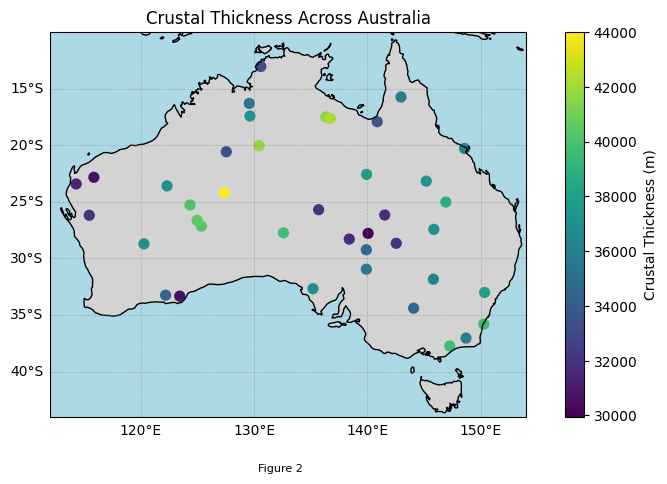

In [32]:
# MAP SETUP - AUSTRALIA

# Define the map projection to use Plate Carree
my_projection=ccrs.PlateCarree()

# Create a Matplotlib figure with a width of 10 inches and height of 5 inches
fig = plt.figure(figsize=(10, 5))

# Create a map axis using the chosen Cartopy projection
ax = plt.axes(projection=my_projection)

# Set the map extent to cover only Australia
ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree())

# Draw coastlines on the map for geographic reference
ax.coastlines()

# Add land areas to the map and color them light gray
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# Add ocean areas to the map and color them light blue
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# Plot locations as a scatter plot
sc_AU = ax.scatter(
    df_AU['Longitude'], # Longitudes of Points (x-coordinates)
    df_AU['Latitude'], # Latitudes of Points (y-coordinates)
    c=df_AU['Crustal Thickness (m)'], # Color the markers by Crustal Thickness
    s=50, # Scale marker size
    cmap="viridis", # Use the 'viridis' colormap for thickness values
    transform=ccrs.PlateCarree()  # Specify the input coordinates are in Plate Carrée (lon/lat) projection
)

# shows how marker color corresponds to crustal thickness
plt.colorbar(sc_AU, label="Crustal Thickness (m)")

# Add a title to the figure
plt.title("Crustal Thickness Across Australia")

# Add latitude and longitude gridlines to the map
gl = ax.gridlines(
    draw_labels=True,     # Show coordinate labels on the map edges
    linewidth=0.5,        # Set gridline thickness
    color="gray",         # Set gridline color
    alpha=0.5,            # Make gridlines semi-transparent
    linestyle="--"        # Use dashed gridlines
)

gl.top_labels = False # Disable labels at the top of the map
gl.right_labels = False # Disable labels on the right side of the map

plt.figtext(0.5, 0.0, "Figure 2", ha="center", fontsize=8)

##-ELLIE'S code

In [26]:
df_SA.head() #show the dataframe table for SA

##-ELLIE'S code

,Longitude,Latitude,Crustal Thickness (m)
0,-74.496015,-49.550410,34322
1,-55.125278,-27.827940,35293
2,-57.220806,-4.890713,35039
3,-46.871095,-13.320275,39410
4,-51.014127,-3.364726,35067


Text(0.5, 0.0, 'Figure 3')

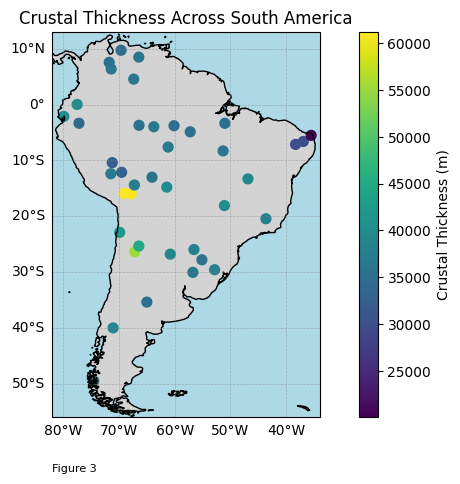

In [33]:
# MAP SETUP & ADD FEATURES - SOUTH AMERICA
#rinse and repeat steps from AU map to create SA map

my_projection=ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=my_projection)

ax.set_extent([-82, -34, -56, 13], crs=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

sc_SA = ax.scatter(
    df_SA['Longitude'],
    df_SA['Latitude'],
    c=df_SA['Crustal Thickness (m)'],
    s=50,
    cmap="viridis",
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc_SA, label="Crustal Thickness (m)")
plt.title("Crustal Thickness Across South America")

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

plt.figtext(0.5, 0.0, "Figure 3", ha="center", fontsize=8)

##-ELLIE'S code

## Interpretation/Discussion

The following analysis examines crustal thickness distributions across Australia and South America using histogram and spatial map data. Additonally, discusses the results and reasoning behind the differences.

**Australia**

The histogram for the Crustal Thickness in Australia, supported by the confidence interval derived from 1,000 bootstrap resamplings of the original 40 measurements, shows that majority of Australian crust is relatively uniform, with a narrow distribution peaking around 36km. The boxplot further confirms this, showing a median of 36km  with no outliers, confirming Australia's continental crust thickness is relatively consistent. This uniformity is also reflected spatially in the map (Fig 2), where most data points are in the teal/green range across Autralia's interior.

The map reveals that the west coast has mostly purple/dark blue dots, indicating thinner crust (30-32 km).
Moving eastward, the dots transition to green and yellow, suggesting thicker crust in central and eastern Australia.
The yellow dot in central Australia represents the thickest data point at approximately 44 km.

Overall, crustal thickness is uniform with a slight trend of increasing thickness from west to east across Australia. The thin crustal values in the west, despite the presence of ancient cratons, can be explained by the fact that they are associated with thick lithospheric keels extending into the mantle; however, this study only measures crustal thickness. The thinner crust in western Australia therefore reflects billions of years of erosion and tectonic stability, while the thicker crust in the east could be associated with more recent orogenic events.

**South America**

The histogram for crustal thickness in South America and the confidence interval, also derived from 1,000 resamplings, reveals that the continental crust is generally thicker and more variable than Australia's, with a wider and flatter distribution peaking around 38km. South America's wider CI compared to Australia's reflects a more geologically active tectonic setting, which the bootstrap method was able to capture despite the limited sample of 40 measurements. South America's histogram is also right-skewed, suggesting some regions have unusually thicker crust corresponding to the Andes. The boxplot supports this, showing a median of approximately 37km with three outliers - two extremely high and one extremely low.

The map supports this (Fig 3), showing purple dots along the eastern Coast of Brazil, suggesting very thin crust (24km). Most of central South America is fairly uniform and sits in the teal/blue range (35-40 km). The two yellow dots in western and central South America mark the thickest areas (48-50 km) and correspond to the outliers identified in the boxplot, which are part of the Andes.

Overall there is a clear trend of crustal thickness decreasing from west to east across South America. This is geologically consistent, as the South American plate is overriding the NAZCA plate along the western edge of the continent, forming the Peru-Chile subduction zone and resulting in significant crustal thickening and the formation of the Andes.

**Comparison**

The combined histograms and maps illustrate the contrasting distributions of the two continents, reflecting their vastly different tectonic settings (Fig 1). This contrast is further reinforced by the boxplots, however, despite these differences, the two distributions overlap from about 35.5 km to 37.5 km, showing similarity despite their different crustal ages. This overlap also reveals that the difference in continents may not be statistically significant given the limited sample size.

The confidence intervals were estimated using a Monte Carlo bootstrapping approach, in which 40 data points for each continent were repeatedly resampled with replacement across 1,000 iterations. Each iteration produced a new estimated mean, and the resulting distribution of 1,000 means was used to calculate the 95% percentile, giving the range in which the true mean crustal thickness likely falls - South America has a significantly wider confidence interval for crustal thickness than Australia, reflecting its vastly different tectonic settings. The Monte Carlo approach was particularly valuable given the small sample size of 40 measurements per continent, as it allows robust statistical inference without requiring a larger and more time-consuming dataset or making assumptions about the underlying data distribution.

Australia is one of the oldest and most stable continental masses on Earth, resulting in a narrow range of crustal thickness. In contrast, South America is very geologically active due to the Peru-Chile subduction zone, producing a much wider range from highly thickened crust beneath the Andes in the west to thin coastal crust in the east.


**Limitations**

 With only 40 randomly sampled points per continent, the dataset may not fully capture localised variations in crustal thickness. While the Monte Carlo bootstrapping method helps account for this uncertainty, a larger and more evenly distributed sample would improve the reliability of these estimates.

#Individual Reflections

###Freddie (Data Steward)

My role was to use the online program Gplates by Cesium (https://portal.gplates.org/cesium/?view=crustal_litho_thickness) to find the thickness of the crust at the random points we found in the previous step. This was rather time consuming, as I had to find each point by hand using the given coordinates. I accumulated all of this data in a google sheets that I made, which I then uploaded here. I then wrote the code that would read the file, seperate the two tables within the sheet and would print out the two tables so that we can see the data points. This code took me a while, with the help of AI, I was able to write a code that went above what we went through in the course. The most difficult part was trying to figure out how to read the two seperate tables in the same google sheets. Overall, my main role was to gather our data that would be used in the later steps. I feel as though we worked very well as a group, we had very clear communication and Clover did really well in her role as the Github person, she made it very easy for me to do my role and ensured that we all completed our tasks on time.


###Ed (Analysis Modelling)

My contribution to the role of analysis modelling was developing bootstrap samples from the crustal thickness data points. This method was straightforward considering the bootstrapping we had performed in the Week 6 Practical. I reflect that my contributions were limited and that the analysis modelling section received significant developments from others, especially in visualisation. Other additions include histograms and boxplots and a general tidying of code. I believe the contribution I made was largely insignificant and I look to contribute more extensively and creatively in my next role; especially in becoming more familiar with these roles and with seeing a finished concept. The rest of my group made my role extremely easy and collaborated well.

###Ellie (Visualisation/Interpretation)

My role was quite important as it was data visualisation and interpretation which was both simple in some parts and more difficult in other parts.
Working on the histograms was straightforward, as the process was similar to what we did in week 5. I then further added titles, a trendline, and extra formatting using the skills learned in week 3, which was also relatively simple. However, I found mapping the data points to be harder and more time-consuming than expected. I originally chose the LambertConformal projection, which distorted the map and clipped the continent, requiring me to switch to PlateCaree projection and adjust the map boundaries, teaching me how projection centres affect the visible map area.

In the interpretation, I was initially confused as to why the crust was generally thinner over areas with cratons, as I expected their age and stability to correspond with greater crust thickness. After some reseach I learned that cratons are thicker when considering the full lithosphere, whereas this study only measures crustal thickness, leading me to rewrite that secton of my interpretation to be more geologically accurate.

###Clover (Github and Integration)

The Github and Integration role is an important one primarily in the beginning and end of the project. I made sure to quickly create the project repository and clearly share the colab file with the group via our canvas page. On the same day I broadly set up the document with sections for each person to start working from. This helped us streamline the organisation of the document and made it easier maintain an understandable narrative flow. Throughout the project I have commited the repository on completion of major steps (ie. data import, analysis, plotting) in order to clearly show our process and contributions.

One surprisingly important element of this role was having to ensure the correct files could be uploaded to github so that the code can run on other devices. Because we randomly generated points using GIS shapefiles I had to determine which files were necessary for the code to run (the .shp and .shx files). Additionally there were some inconsistencies with naming of our main spreadsheet across the sections so I made sure to improve consistency so that only one version of the main data file had to be uploaded. Because this role didn't require as much hands on work during the week I used my time to coordinate timeline reminders and ensure all group members were able to be in communicate. I also provided reminders to complete the reflections before the due date.

###Justin (Narrative)
My role as the narrator, as well as assisting with the random lat-lon point generation, was interesting but also difficult. Like with any group assignment, I can sometimes get carried away and develop a myopic view of what needs to be done, stemming from a false consensus that everyone is on the same page as me. An example of this was expecting diffrent data visualization and what best would convey the results best. However, good teamwork relies on clear communication, and we worked really well together, bouncing ideas and reach an agreement while learning as we go.

I also found the random point generation to be a challenging step in the process. It required some transdisciplinary skills, using GIS software to source an appropriate shapefile. Initially, the team and I thought about just using a random coordinate website (like random.org). However, programming this into the notebook allowed for repeatability and scalability. By scripting it, anyone who accesses the code can implement their own shapefile of interest and reproduce the experiment. Additionally, because the team was initially unsure of the exact number of points required, writing the code gave us the flexibility to easily adjust the number of observations on the fly.

###Owen (Quality Control/Reproducibility)
My role as the quality control/reproductability lead was to ensure the project was both portraying the results we aimed to find, while also verifying the smooth running and reproductibility of the code. I can relfect that my role was fairly straightforward, however required attention to detail in all coding facets, and further, the results that my team members had concluded upon. This being said, the attentiveness and care shown by my team members made my role as quality control fairly trouble-free. Specific areas I focused on involved consistency in code, especially in repeated methods - like the crustal thickness maps generated for both Australia and South America, and moreover, complex figures like the Crustal Depth Distribution Graph - all of which effectively represented our desired results.

In terms of reproductability, I found the code easy to follow and understand, especially with the narration of the steps taken to reach the results in most lines of code (defined by the # next to or above each comnponent). As such, I found that the experiment would be easy to replicate if a similar question were to be asked, or a different set of figures and sets of data were to be used (for example different areas of the world etc.).